# Q2 Jupyter notebook - Student ID 5558899

### Note: Markdown cells were skipped and code comments are kept at a minimum given the instructions for Assignment 3 (compared to my submissions for Assignment 1 and 2)

In [ ]:

# Imports and DF setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('Q2_cities.csv')
cities = df['city'].values
X_raw = df.drop(columns=['city'])

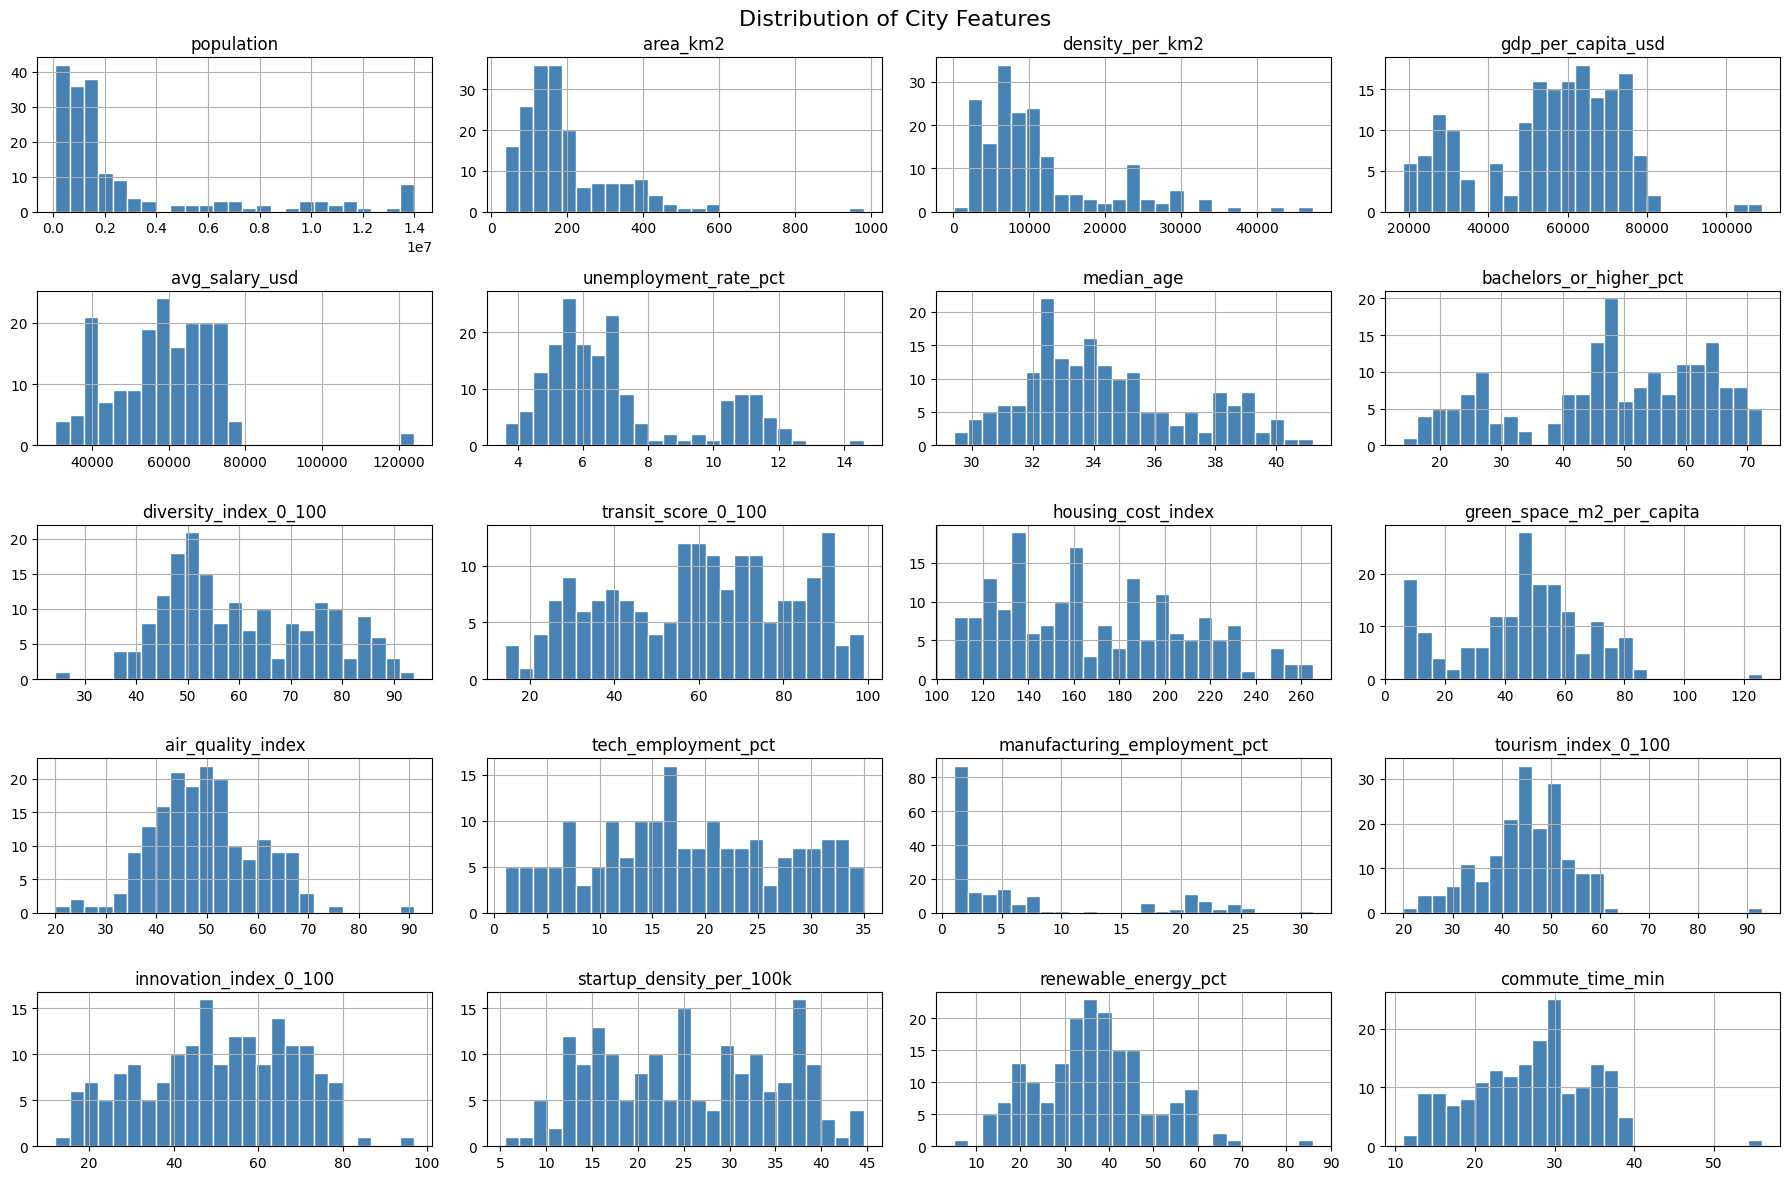

In [3]:
# quick look at distributions across all features
X_raw.hist(bins=25, figsize=(18, 12), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of City Features', fontsize=16)
plt.tight_layout()
plt.show()

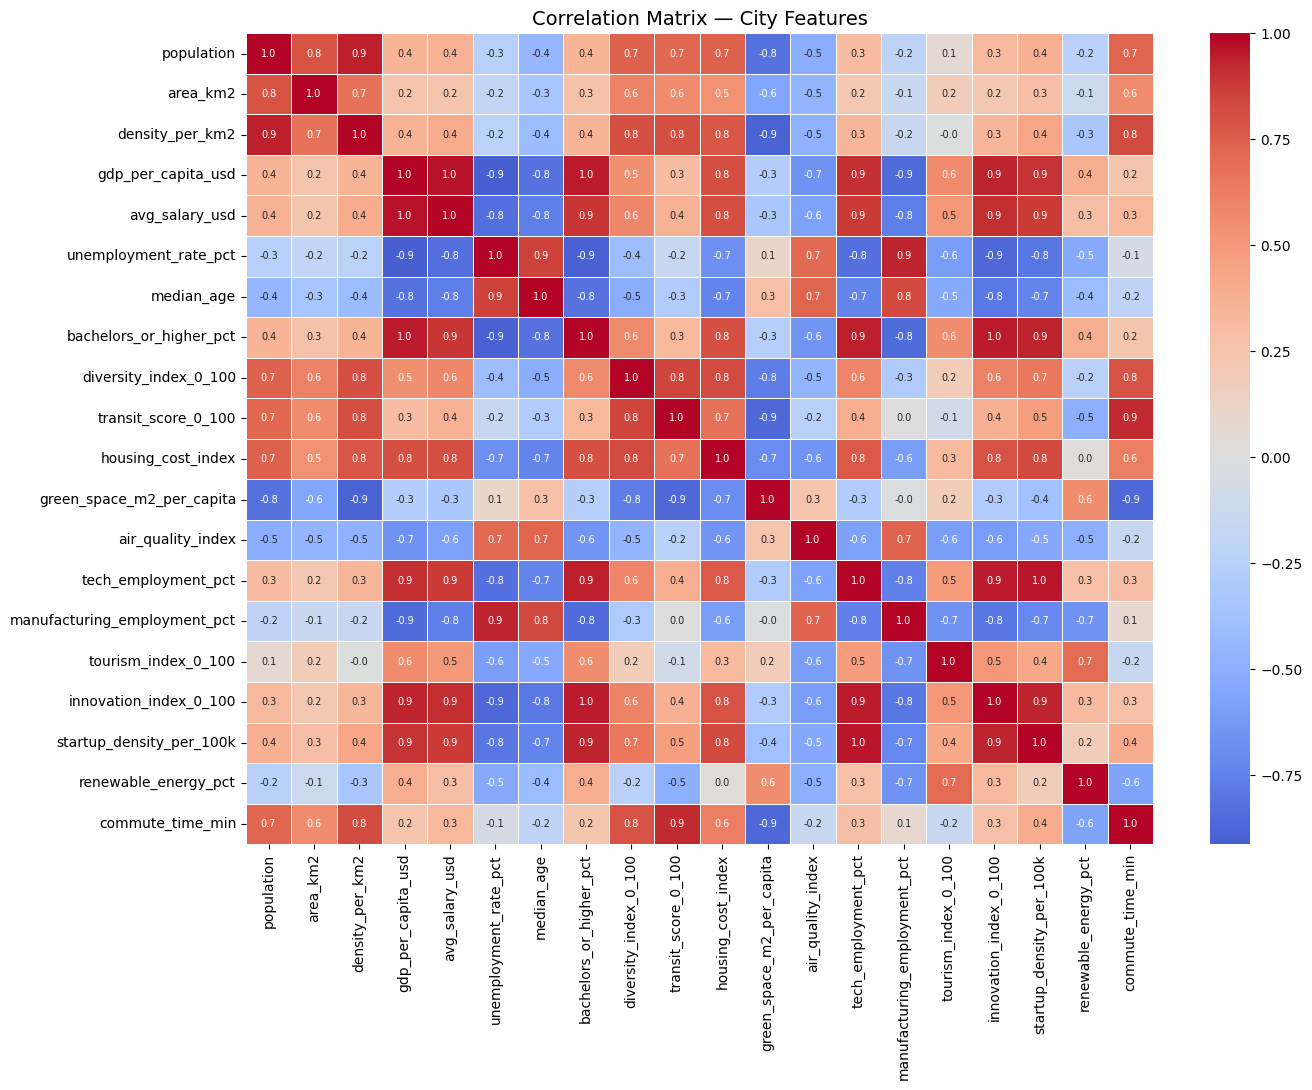

In [4]:
# correlation heatmap - helps spot clusters of related variables before doing anything fancier
plt.figure(figsize=(14, 11))
corr = X_raw.corr()
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title('Correlation Matrix \u2014 City Features', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# population, area, density and startup_density are heavily right-skewed, so log them
# this stops the few giant cities from dominating distance calculations
skewed = ['population', 'area_km2', 'density_per_km2', 'startup_density_per_100k']
X_proc = X_raw.copy()
X_proc[skewed] = np.log1p(X_raw[skewed])

# standardise - PCA and k-means both care about scale, so everything needs to be on the same footing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_proc)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_raw.columns)

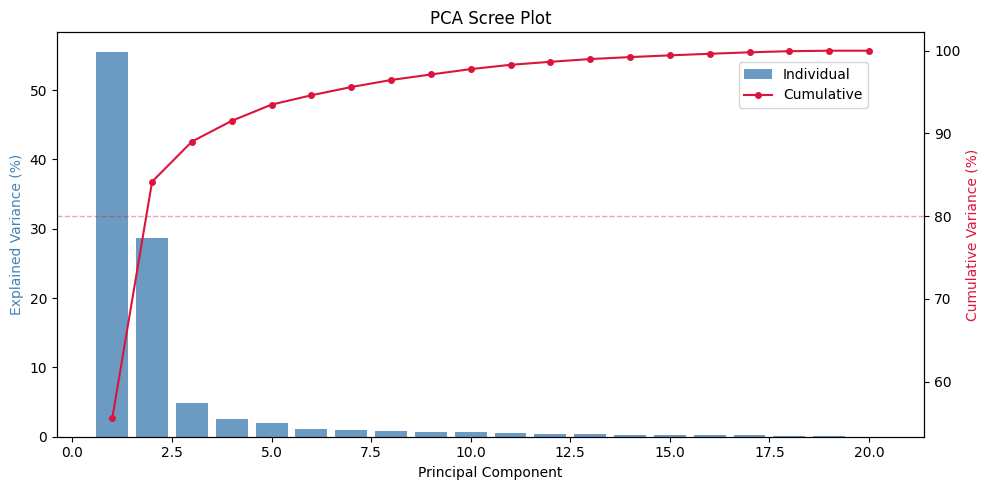

Variance explained by first 5 PCs: [55.5 84.2 89.  91.5 93.5]


In [6]:
# fit PCA on all 20 components first just to look at the variance breakdown
pca_full = PCA()
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(1, len(explained)+1), explained * 100, color='steelblue', alpha=0.8, label='Individual')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative)+1), cumulative * 100, color='crimson', marker='o', markersize=4, label='Cumulative')
ax2.set_ylabel('Cumulative Variance (%)', color='crimson')
ax2.axhline(80, color='crimson', linestyle='--', alpha=0.4, linewidth=1)
plt.title('PCA Scree Plot')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

print("Variance explained by first 5 PCs:", np.round(cumulative[:5] * 100, 1))


Top PC1 loadings (sorted):
housing_cost_index          0.283
bachelors_or_higher_pct     0.276
startup_density_per_100k    0.276
gdp_per_capita_usd          0.275
innovation_index_0_100      0.274
tech_employment_pct         0.269
avg_salary_usd              0.268
median_age                 -0.253
Name: PC1, dtype: float64

Top PC2 loadings (sorted):
renewable_energy_pct         0.369
commute_time_min            -0.328
green_space_m2_per_capita    0.320
density_per_km2             -0.319
population                  -0.318
transit_score_0_100         -0.303
area_km2                    -0.253
tourism_index_0_100          0.250
Name: PC2, dtype: float64


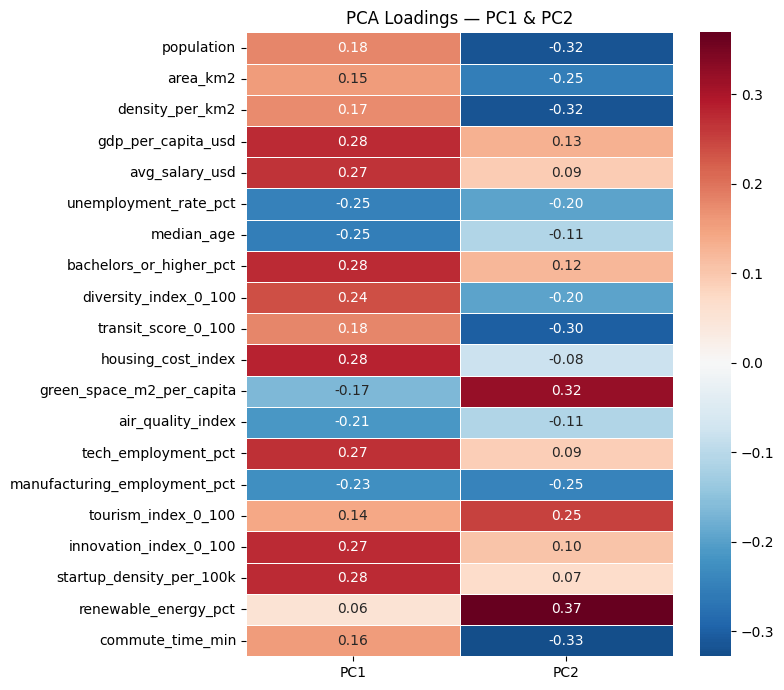

In [7]:
# 2 components for plotting, 5 for the actual clustering (captures ~93% of variance)
pca2 = PCA(n_components=2)
coords2 = pca2.fit_transform(X_scaled)

pca5 = PCA(n_components=5)
coords5 = pca5.fit_transform(X_scaled)

# check the loadings to understand what the first two components actually represent
loadings = pd.DataFrame(pca2.components_.T, index=X_raw.columns, columns=['PC1', 'PC2']).round(3)
print("\nTop PC1 loadings (sorted):"); print(loadings['PC1'].sort_values(key=abs, ascending=False).head(8))
print("\nTop PC2 loadings (sorted):"); print(loadings['PC2'].sort_values(key=abs, ascending=False).head(8))

plt.figure(figsize=(8, 7))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('PCA Loadings \u2014 PC1 & PC2')
plt.tight_layout()
plt.show()

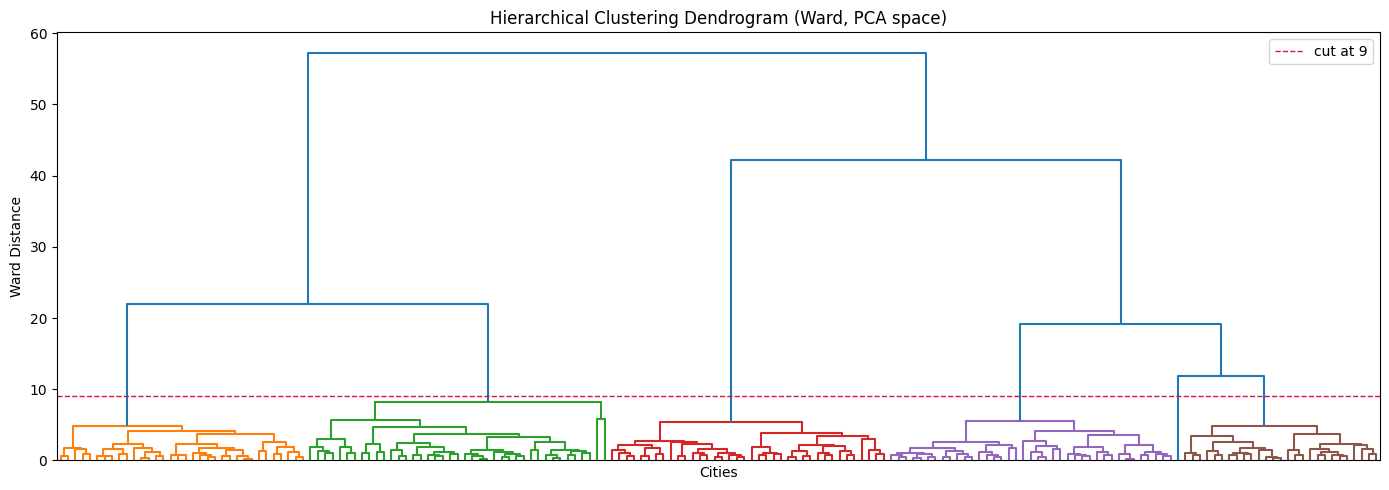

In [8]:
# hierarchical clustering with ward linkage on the 5-pc space
# ward minimises the increase in within-cluster variance at each merge step
Z = linkage(coords5, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, no_labels=True, color_threshold=9)
plt.axhline(y=9, color='crimson', linestyle='--', linewidth=1, label='cut at 9')
plt.title('Hierarchical Clustering Dendrogram (Ward, PCA space)')
plt.xlabel('Cities'); plt.ylabel('Ward Distance')
plt.legend()
plt.tight_layout()
plt.show()

# cut the tree at height 9 - gives 4 main branches
hier_labels = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(coords5)

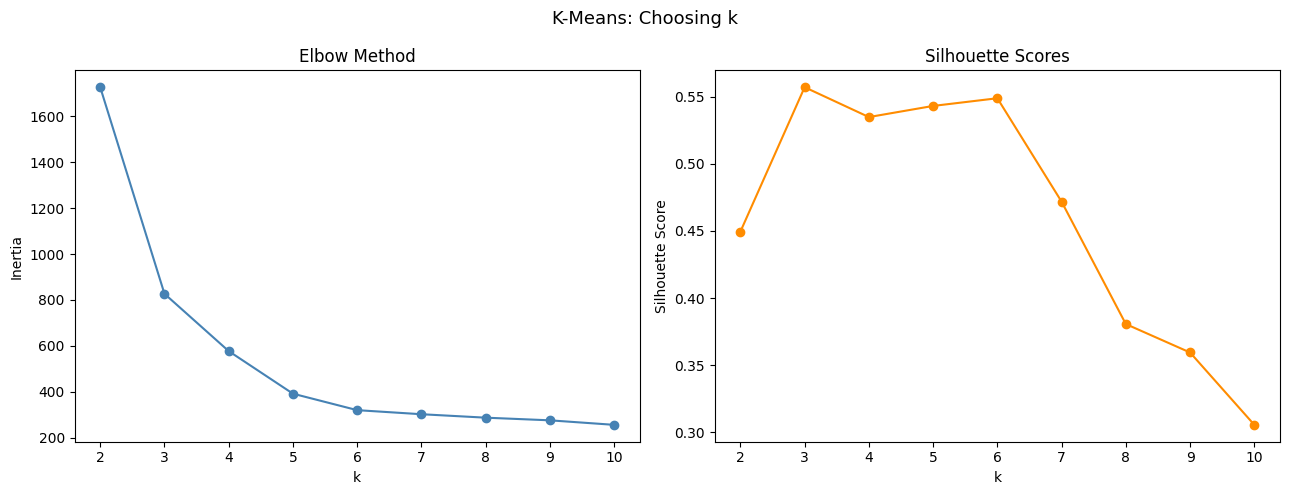

Silhouette scores: {2: 0.449, 3: 0.557, 4: 0.535, 5: 0.543, 6: 0.549, 7: 0.472, 8: 0.381, 9: 0.359, 10: 0.306}


In [9]:
# sweep k from 2 to 10 and track both inertia and silhouette
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(coords5)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(coords5, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(k_range, inertias, marker='o', color='steelblue')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow Method')
ax2.plot(k_range, sil_scores, marker='o', color='darkorange')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette Scores')
plt.suptitle('K-Means: Choosing k', fontsize=13)
plt.tight_layout()
plt.show()

print("Silhouette scores:", {k: round(s, 3) for k, s in zip(k_range, sil_scores)})

# k=4 consistent with the dendrogram, silhouette only marginally lower than k=3
# 30 initialisations to reduce chance of getting stuck in a bad local minimum
km_final = KMeans(n_clusters=4, n_init=30, random_state=42)
km_labels = km_final.fit_predict(coords5)

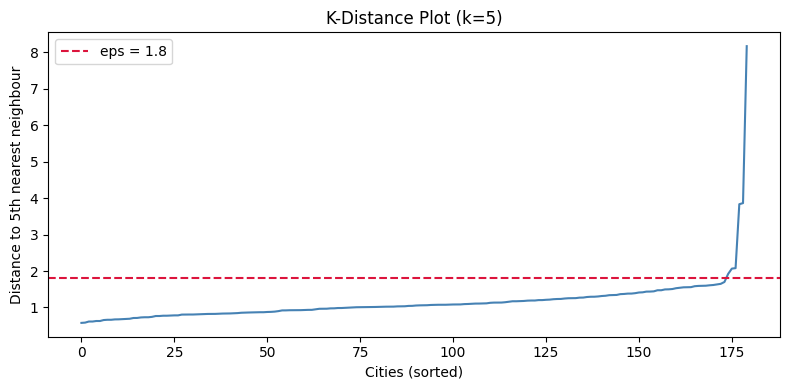


DBSCAN: 2 clusters, 4 noise points
Cluster sizes: {-1: 4, 0: 139, 1: 37}


In [10]:
# k-distance plot to pick eps for DBSCAN - look for the elbow
nbrs = NearestNeighbors(n_neighbors=5).fit(coords5)
distances, _ = nbrs.kneighbors(coords5)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist, color='steelblue')
plt.axhline(y=1.8, color='crimson', linestyle='--', label='eps = 1.8')
plt.xlabel('Cities (sorted)'); plt.ylabel('Distance to 5th nearest neighbour')
plt.title('K-Distance Plot (k=5)')
plt.legend()
plt.tight_layout()
plt.show()

# eps=1.8, min_samples=5 from the k-distance elbow above
db = DBSCAN(eps=1.8, min_samples=5)
db_labels = db.fit_predict(coords5)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"\nDBSCAN: {n_clusters_db} clusters, {n_noise} noise points")
print("Cluster sizes:", pd.Series(db_labels).value_counts().sort_index().to_dict())

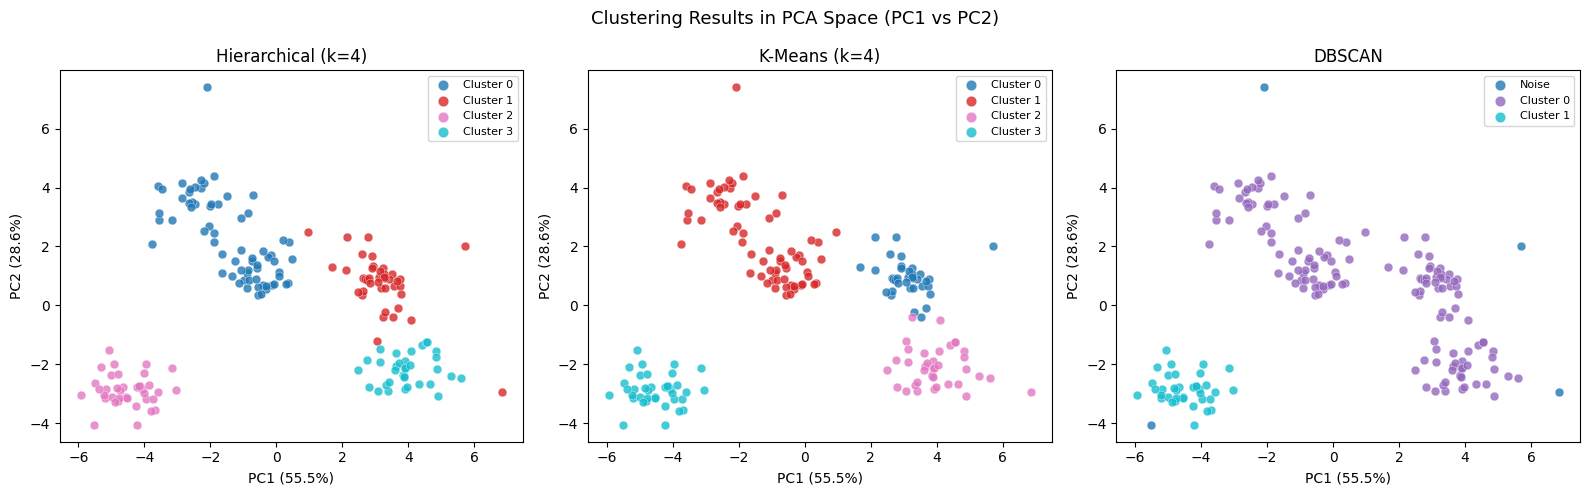

In [11]:
# all three methods side by side in the 2d PCA space
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
method_labels = [hier_labels, km_labels, db_labels]
titles = ['Hierarchical (k=4)', 'K-Means (k=4)', 'DBSCAN']

for ax, labels, title in zip(axes, method_labels, titles):
    unique = sorted(set(labels))
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(unique)))
    for cl, col in zip(unique, colors):
        mask = labels == cl
        label_str = f'Cluster {cl}' if cl != -1 else 'Noise'
        ax.scatter(coords2[mask, 0], coords2[mask, 1], c=[col], label=label_str, s=40, alpha=0.8, edgecolors='white', linewidths=0.3)
    ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title)
    ax.legend(fontsize=8, markerscale=1.2)

plt.suptitle('Clustering Results in PCA Space (PC1 vs PC2)', fontsize=13)
plt.tight_layout()
plt.show()


Cluster profiles (feature means):
 cluster                                0          1           2           3
population                    1798369.22  644672.72  9531236.39  1585320.92
area_km2                          166.46     128.56      371.12      165.88
density_per_km2                 10496.95    4851.59    25538.65     9405.35
gdp_per_capita_usd              73967.28   54023.41    68021.37    26932.08
avg_salary_usd                  73473.58   55960.63    68307.97    39283.55
unemployment_rate_pct               5.05       6.66        5.70       11.17
median_age                         32.78      34.31       32.10       38.56
bachelors_or_higher_pct            65.97      46.21       58.51       24.30
diversity_index_0_100              69.16      48.27       81.84       53.58
transit_score_0_100                69.56      36.62       88.71       62.82
housing_cost_index                193.27     149.25      223.60      125.46
green_space_m2_per_capita          45.68      65.31 

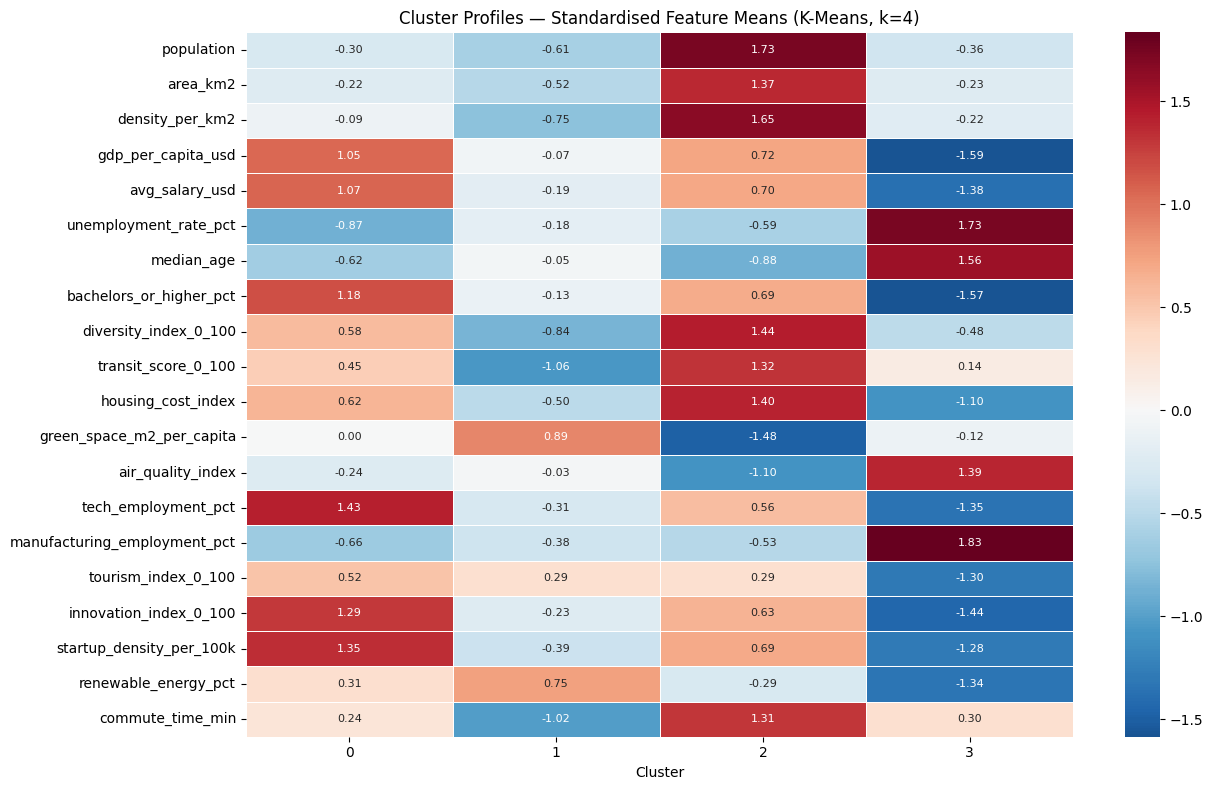


Cluster sizes:
0    36
1    68
2    38
3    38
Name: count, dtype: int64

Cluster 0 sample cities: Highford, Newsprings, Whitelake, Dunevale, Oldstead, Cedarhaven

Cluster 1 sample cities: Longstead, Pinehurst, Harborshire, Driftridge, Cedarside, Oldbury

Cluster 2 sample cities: Cedarton, Pinelake, Kettleview, Brightsprings, Elmbury, Moorwood

Cluster 3 sample cities: Kettleside, Coralport, Mapleton, Yorkside, Juniperhurst, Kettlevale


In [12]:
# cluster profiling - use k-means labels as the main result
df_clustered = X_raw.copy()
df_clustered['cluster'] = km_labels
df_clustered['city'] = cities

profile = df_clustered.groupby('cluster')[X_raw.columns].mean().round(2)
print("\nCluster profiles (feature means):\n", profile.T.to_string())

# express each cluster mean as a z-score relative to the full dataset
# makes it easy to see what's distinctive about each cluster
profile_z = (profile - X_raw.mean()) / X_raw.std()

plt.figure(figsize=(13, 8))
sns.heatmap(profile_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Cluster Profiles \u2014 Standardised Feature Means (K-Means, k=4)')
plt.xlabel('Cluster')
plt.tight_layout()
plt.show()

print("\nCluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index())

for cl in sorted(df_clustered['cluster'].unique()):
    sample = df_clustered[df_clustered['cluster'] == cl]['city'].values[:6]
    print(f"\nCluster {cl} sample cities: {', '.join(sample)}")